# Captura y Procesamiento de Señal PPG Cruda desde PineTime

Este notebook implementa y compara distintos métodos para la captura de señales PPG (Photoplethysmography) crudas desde el dispositivo **PineTime**, utilizando el sensor óptico **HRS3300**.  

## Objetivo

Capturar datos de PPG en tiempo real desde el sensor HRS3300 del Pinetime mediante comunicación BLE, procesarlos y guardarlos en diferentes formatos según las necesidades del análisis posterior.

## Métodos de Captura Implementados

1. **Captura CSV pura**: Formato optimizado para alimentar modelos de ML entrenados
2. **Captura con plots individuales**: Guarda cada frame de la señal como imagen PNG
3. **Captura con video**: Genera videos MP4 de la señal cruda y procesada en tiempo real

Cada método incluye:
- Almacenamiento de datos en CSV (valores + timestamps)
- Metadatos del experimento en JSON
- Filtrado pasa-banda (0.5-3.0 Hz)
- Detección de picos y estimación de frecuencia cardíaca
- Visualización en tiempo real

## Librerías e Imports

A continuación se importan las librerías necesarias para la adquisición de datos, procesamiento de señales, visualización y almacenamiento de resultados.


In [ ]:
pip install pandas numpy scipy ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import hrs_analysis_tools
import importlib
importlib.reload(hrs_analysis_tools)

<module 'hrs_analysis_tools' from 'c:\\Users\\andre\\Downloads\\pinetime\\pruebas\\ppg_analysis\\hrs_analysis_tools.py'>

# Capturar y Guardar CSV

Este módulo captura datos PPG del reloj Pinetime Dev Kit y guardarlos en CSV con timestamps y metadatos. Para análisis posterior con el modelo de ML entrenado.

Button(description='mark', style=ButtonStyle())

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

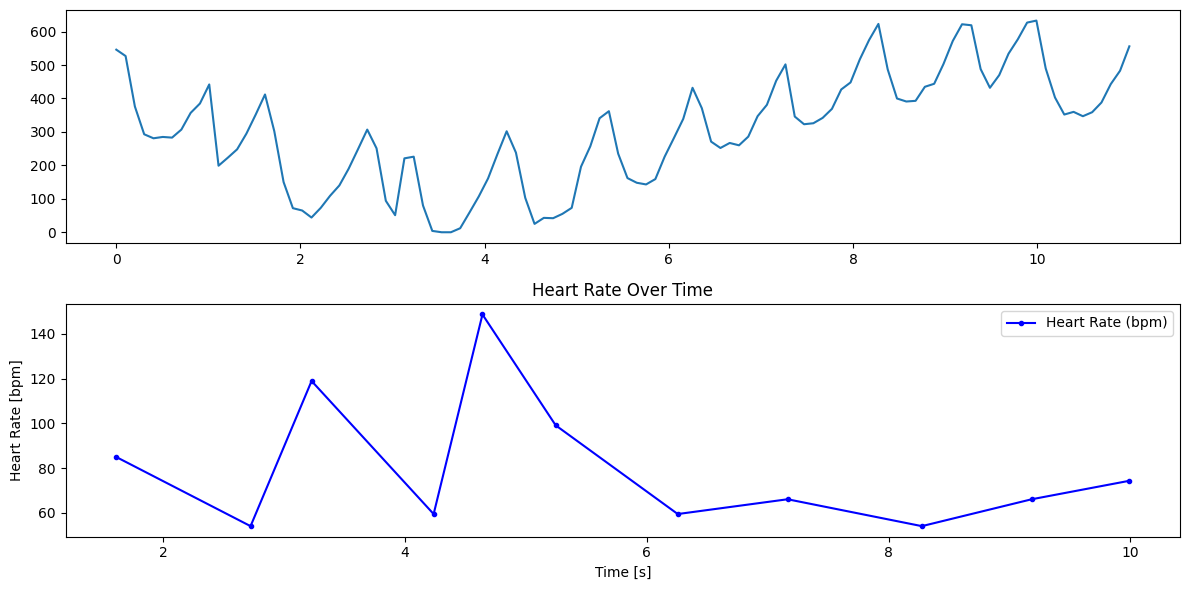

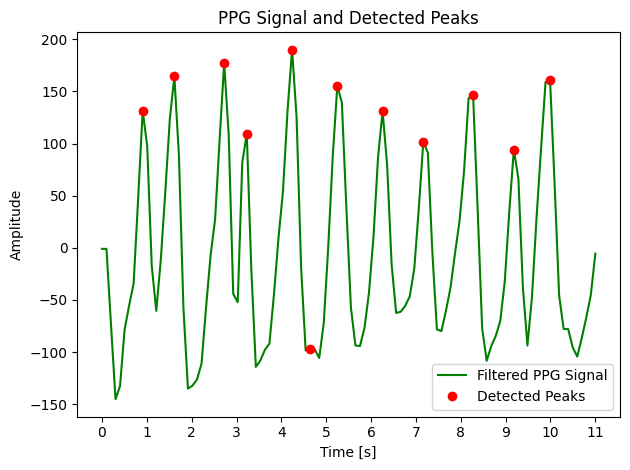

Average Heart Rate: 80.46 bpm


CancelledError: 

In [ ]:
%matplotlib inline
import time
import pylab as pl
from IPython import display
import asyncio
from bleak import BleakClient
import time
import struct
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

import time
import asyncio
from bleak import BleakClient
import time
import struct
import json
import ipywidgets as widgets 
from matplotlib.ticker import MultipleLocator

  

# Dirección MAC del reloj (ajusta a tu dispositivo)
address = "f2:2b:66:04:27:68"

# UUID "2A39" (BLE estándar, pero en este fork se usa
# para exponer el buffer crudo del sensor HRS3300).
MODEL_NBR_UUID = "2A39"

# Metadatos: se guardan junto al CSV para trazabilidad del dataset.
metadata = {
    "infinitime_version" : 1.14,
    "led_current_mA": 12,
    "delay_ms": 50, # wait time between conversion cycle
    "description": "steady hand led12"
}


# =============================================================================
# Generador asíncrono: lectura continua de buffers PPG crudos (64 muestras)
# =============================================================================
async def main(address):
    """
    Async generator que se conecta por BLE al Pinetime y lee continuamente
    el characteristic definido por MODEL_NBR_UUID.

    Cada lectura devuelve un paquete de 128 bytes interpretado como 64 enteros
    sin signo de 16 bits (uint16), en little-endian.

    Yields
    ------
    np.ndarray
        Vector de longitud 64 (dtype implícito int) con PPG crudo del sensor.
    """
    async with BleakClient(address) as client:
        while True:
            # Lee los 128 bytes del characteristic (64 * 2 bytes)
            raw_data = await client.read_gatt_char(MODEL_NBR_UUID)

            # Interpreta los bytes como 64 unsigned shorts (uint16)
            int_array = np.array(list(struct.unpack('<64H', raw_data)))

            # Entrega el buffer a quien consume el generador (hrs_analysis_tools.process)
            yield int_array

            # Pausa entre lecturas BLE (no es el sampling real del sensor; es el pull BLE)
            await asyncio.sleep(2)


# =============================================================================
# Archivos de salida (dataset)
# =============================================================================
# Timestamp para agrupar archivos del mismo experimento
timestamp = str(int(time.time()))

# CSV de valores (una muestra por fila)
data_file = open(f"data/{timestamp}_data_10hz.csv", "w")

# CSV de tiempos (una marca temporal por muestra; misma cantidad de filas que data.csv)
time_file = open(f"data/{timestamp}_time.csv", "w")

# Metadatos del experimento (JSON)
with open(f"data/{timestamp}_metadatadata.json", "w") as metadata_file:
    metadata_file.write(json.dumps(metadata, indent=4))


# =============================================================================
# Marcadores manuales (botón): útil para anotar eventos durante la adquisición
# =============================================================================
def click(arg):
    """
    Callback de ipywidgets para registrar un 'mark' manual.
    Escribe un timestamp (epoch) en un archivo separado de marcas.
    """
    with open(f"data/{timestamp}_mark.csv", "a") as mark_file:
        mark_file.write(str(time.time()) + "\n")
        mark_file.flush
        print("xx")
        
# creating button 
button = widgets.Button(description = 'mark') 
button.on_click(click)


# =============================================================================
# Estado global para guardado incremental
# =============================================================================
# prev_len controla cuánto del agregado ya fue escrito a disco, para solo guardar
# las muestras nuevas (evita re-escribir el buffer completo cada iteración).
prev_len = 0

# dt: aproximación del periodo de muestreo (según settings del sensor)
# OJO: delay_ms es el "wait time" entre conversiones; aquí se usa como aproximación.
dt = metadata["delay_ms"] / 1000.0  # 50ms -> 20 Hz aprox


# =============================================================================
# Listener por iteración: guardado incremental + estimación HR + visualización
# =============================================================================
def foo(agg, a1, a2):
    """
    Función callback que se ejecuta en cada iteración del agregador.

    Parámetros
    ----------
    agg : np.ndarray
        Señal agregada completa (concatenación reconstruida) producida por
        hrs_analysis_tools.process(). Crece con el tiempo.
    a1 : np.ndarray
        Buffer previo (64 muestras) leído del reloj.
    a2 : np.ndarray
        Buffer actual (64 muestras) leído del reloj.

    Responsabilidades
    -----------------
    1) Guardar a disco SOLO el segmento nuevo de agg (incremental).
    2) Tomar una ventana reciente para graficar y estimar frecuencia cardiaca (HR).
    3) Filtrar, detectar picos y calcular HR aproximado en tiempo real.
    """
    global prev_len, dt

    # --- NUEVO: tomar solo lo nuevo desde la última vez ---
    if prev_len == 0:
        # primera llamada: si quieres NO guardar histórico, arranca vacío:
        # prev_len = len(agg)
        # return
        pass

    # Segmento nuevo desde la última ejecución
    new_segment = agg[prev_len:]
    prev_len = len(agg)

    # --- Guardado: una fila por muestra (más útil para ML) ---
    # Se asigna un tiempo base t0 y se asume muestreo uniforme cada dt.
    # Nota: esto es una aproximación; para precisión real se requeriría timestamping
    # exacto por muestra en firmware o conocer el "deltaMs" real.
    t0 = time.time()
    for i, v in enumerate(new_segment):
        time_file.write(f"{t0 + i*dt}\n")
        data_file.write(f"{int(v)}\n")
        print(f"{t0 + i*dt}, {int(v)}")


    time_file.flush()
    data_file.flush()

    # --- Tu parte de graficado puede seguir igual, usando agg ---
    # Ventana reciente: últimos ~120 puntos, excluyendo los últimos 10 (margen de seguridad)
    aggregator2 = agg[max(-120, -len(agg)):-10]

    # Normalización simple (quita offset) para visualización
    ppg_signal = aggregator2 - min(aggregator2)

    time_space = np.linspace(0, len(aggregator2)/10, len(aggregator2))

    # Step 1: Apply a bandpass filter to remove noise
    def bandpass_filter(signal, lowcut, highcut, fs, order=5):
        """
        Filtro pasa-banda Butterworth + filtfilt (cero fase).

        Parameters
        ----------
        signal : array-like
            Señal PPG de entrada.
        lowcut : float
            Frecuencia de corte baja (Hz).
        highcut : float
            Frecuencia de corte alta (Hz).
        fs : float
            Frecuencia de muestreo (Hz).
        order : int
            Orden del filtro.

        Returns
        -------
        np.ndarray
            Señal filtrada.
        """
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = butter(order, [low, high], btype='band')
        filtered_signal = filtfilt(b, a, signal)
        return filtered_signal

    # Frecuencia de muestreo usada para filtrado/detección (se mantiene EXACTO como está)
    fs = 10  # Sampling frequency (10 Hz)

    # Banda típica de HR: 0.5–3.0 Hz ~ 30–180 bpm
    lowcut = 0.5  # Lower bound of heart rate (30 bpm)
    highcut = 3.0  # Upper bound of heart rate (180 bpm)
    filtered_ppg = bandpass_filter(ppg_signal, lowcut, highcut, fs)

    # Step 2: Detect peaks in the filtered PPG signal
    # distance=fs/2.5: impone separación mínima entre picos (evita detectar duplicados)
    peaks, _ = find_peaks(filtered_ppg, distance=fs/2.5)  # Roughly expect a peak every ~0.4s (150 bpm max)

    # Step 3: Calculate heart rate from peaks
    peak_times = time_space[peaks]  # Time of each detected peak
    rr_intervals = np.diff(peak_times)  # Time between consecutive peaks (in seconds)
    heart_rate = 60 / rr_intervals  # Convert RR intervals to heart rate in bpm

    
    # Step 4: Visualize the results
    # Limpia la salida del notebook para animación "en vivo"
    display.clear_output(wait=True)
    display.display(button)
    display.display(pl.gcf())

    # Figura principal: señal original y HR
    pl.figure(figsize=(12, 6))

    pl.subplot(2, 1, 1)
    pl.plot(time_space, ppg_signal, label='Original PPG Signal')

    pl.subplot(2, 1, 2)
    pl.plot(peak_times[1:], heart_rate, 'b.-', label='Heart Rate (bpm)')
    pl.title('Heart Rate Over Time')
    pl.xlabel('Time [s]')
    pl.ylabel('Heart Rate [bpm]')
    pl.legend()

    pl.tight_layout()


    # Figura extra: señal filtrada y picos detectados
    pl.figure()
    pl.plot(time_space, filtered_ppg, label='Filtered PPG Signal', color='green')
    pl.plot(time_space[peaks], filtered_ppg[peaks], 'ro', label='Detected Peaks')
    pl.title('PPG Signal and Detected Peaks')
    pl.xlabel('Time [s]')
    pl.ylabel('Amplitude')
    pl.legend()
    ax = pl.gca()
    ax.xaxis.set_major_locator(MultipleLocator(1))


    pl.tight_layout()
    pl.show()

    
    # Promedio simple (puede ser inestable si hay pocos picos)
    print("Average Heart Rate: {:.2f} bpm".format(np.mean(heart_rate)))



# =============================================================================
# Ejecución principal
# =============================================================================
# - gen: generador de buffers crudos (64 muestras)
# - hrs_analysis_tools.process: reconstruye la señal continua a partir de buffers
#   solapados (según la lógica del firmware/InfiniTime).
try:
    gen = main(address)
    await hrs_analysis_tools.process(gen, iteration_listener_func=foo )
finally:
    pass
    #data_file.close()
    #time_file.close()


# Capturar y Guardar Plots

Este módulo captura datos PPG del reloj Pinetime Dev Kit y guarda cada frame de la señal como imagen PNG, al finalizar la captura también guarda una imagen PNG con la señal completa cruda y filtrada, además de almacenar los datos en CSV y metadatos en JSON.

Button(description='mark', style=ButtonStyle())

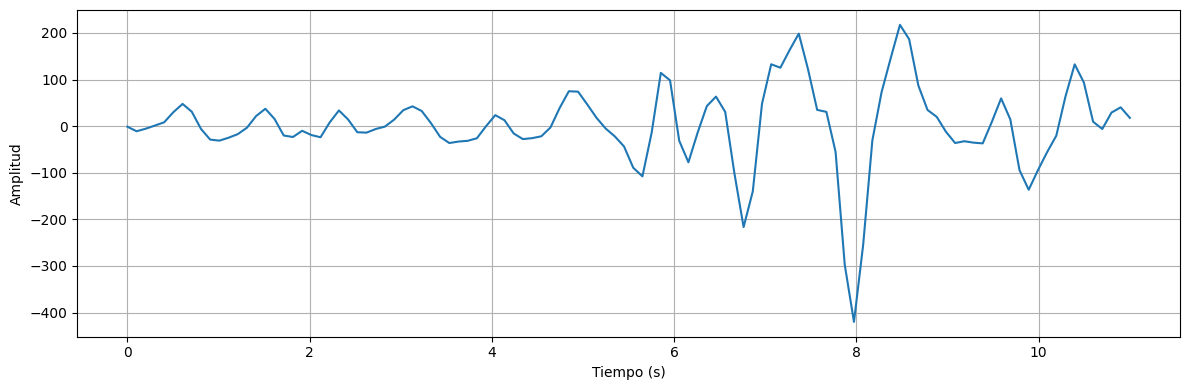

ValueError: min() iterable argument is empty

In [4]:
%matplotlib inline
import time
import asyncio
import struct
import json
import os

import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
from IPython import display
from bleak import BleakClient
from scipy.signal import butter, filtfilt, find_peaks
import ipywidgets as widgets

# =============================================================================
# Configuración
# =============================================================================

address = "f2:2b:66:04:27:68"
MODEL_NBR_UUID = "2A39"

metadata = {
    "infinitime_version": 1.14,
    "led_current_mA": 12,
    "delay_ms": 50,
    "description": "steady hand led12"
}

# =============================================================================
# Generator BLE
# =============================================================================

async def main(address):
    async with BleakClient(address) as client:
        while True:
            raw_data = await client.read_gatt_char(MODEL_NBR_UUID)
            int_array = np.array(list(struct.unpack('<64H', raw_data)))
            yield int_array
            await asyncio.sleep(2)

# =============================================================================
# Salidas
# =============================================================================

timestamp = str(int(time.time()))

os.makedirs("data", exist_ok=True)
os.makedirs(f"plots/{timestamp}", exist_ok=True)

data_file = open(f"data/{timestamp}_data_10hz.csv", "w")
time_file = open(f"data/{timestamp}_time.csv", "w")

with open(f"data/{timestamp}_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

# =============================================================================
# Botón de marcas
# =============================================================================

def click(arg):
    with open(f"data/{timestamp}_mark.csv", "a") as mark_file:
        mark_file.write(str(time.time()) + "\n")
        mark_file.flush()
        print("mark")

button = widgets.Button(description="mark")
button.on_click(click)

# =============================================================================
# Estado global
# =============================================================================

prev_len = 0
plot_counter = 0
full_signal = None

dt = metadata["delay_ms"] / 1000.0

# =============================================================================
# Filtro
# =============================================================================

def bandpass_filter(signal, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    b, a = butter(order,
                  [lowcut / nyq, highcut / nyq],
                  btype="band")
    return filtfilt(b, a, signal)

# =============================================================================
# Callback principal
# =============================================================================

def foo(agg, a1, a2):
    global prev_len, plot_counter, full_signal

    # Guardar señal completa
    full_signal = agg.copy()

    # Guardado incremental
    new_segment = agg[prev_len:]
    prev_len = len(agg)

    t0 = time.time()
    for i, v in enumerate(new_segment):
        time_file.write(f"{t0 + i*dt}\n")
        data_file.write(f"{int(v)}\n")

    time_file.flush()
    data_file.flush()

    # Ventana reciente
    window = agg[max(-120, -len(agg)):-10]
    if len(window) < 20:
        return

    ppg = window - np.min(window)
    time_space = np.linspace(0, len(ppg)/10, len(ppg))

    fs = 10
    filtered = bandpass_filter(ppg, 0.5, 3.0, fs)

    peaks, _ = find_peaks(filtered, distance=fs/2.5)

    hr_text = "HR: --"
    if len(peaks) >= 2:
        rr = np.diff(time_space[peaks])
        rr = rr[rr > 0]
        if len(rr):
            hr_text = f"HR: {np.mean(60/rr):.1f} bpm"

    # Visualización en vivo
    display.clear_output(wait=True)
    display.display(button)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(time_space, filtered)
#    if len(peaks):
#        ax.plot(time_space[peaks], filtered[peaks], "x", label="Picos")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    fig.tight_layout()

    # Guardar frame
    fname = f"plots/{timestamp}/ppg_{plot_counter:06d}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight", pad_inches=0.05)
    plot_counter += 1

    plt.show()
    plt.close(fig)

# =============================================================================
# Ejecución
# =============================================================================

try:
    gen = main(address)
    await hrs_analysis_tools.process(gen, iteration_listener_func=foo)

finally:
    data_file.close()
    time_file.close()

    # =============================================================================
    # Plot final de señal completa (recortando inicio y fin)
    # =============================================================================

    if full_signal is not None and len(full_signal) > 0:
        samples_to_cut = int(10 / dt)  # 10 segundos

        # Asegura que la señal sea suficientemente larga
        if len(full_signal) > 2 * samples_to_cut:

            trimmed_signal = full_signal[samples_to_cut:-samples_to_cut]
            t = np.arange(len(trimmed_signal)) * dt

            # -------- Señal cruda --------
            fig, ax = plt.subplots(figsize=(16, 5))
            ax.plot(t, trimmed_signal, linewidth=0.6)
            ax.set_title("PPG completa (sin primeros y últimos 5 s) – cruda")
            ax.set_xlabel("Tiempo (s)")
            ax.set_ylabel("Amplitud")
            ax.grid(True)
            fig.tight_layout()

            fig.savefig(
                f"plots/{timestamp}/ppg_full_raw_trimmed.png",
                dpi=200,
                bbox_inches="tight"
            )
            plt.close(fig)

            # -------- Señal filtrada --------
            fs_full = 1 / dt
            filtered_full = bandpass_filter(
                trimmed_signal - np.min(trimmed_signal),
                lowcut=0.5,
                highcut=3.0,
                fs=fs_full
            )

            fig, ax = plt.subplots(figsize=(16, 5))
            ax.plot(t, filtered_full, linewidth=1, color='red')
            ax.set_title("PPG completa (sin primeros y últimos 10 s) – filtrada")
            ax.set_xlabel("Tiempo (s)")
            ax.set_ylabel("Amplitud")
            ax.grid(True)
            fig.tight_layout()

            fig.savefig(
                f"plots/{timestamp}/ppg_full_filtered_trimmed.png",
                dpi=200,
                bbox_inches="tight"
            )
            plt.close(fig)

        else:
            print("⚠️ Señal demasiado corta para recortar 5 s al inicio y al final")



# Capturar y Guardar Video

Este módulo captura datos PPG del reloj Pinetime Dev Kit y genera videos MP4 de la señal cruda y procesada con un retraso de alrededor de 15 segundos, porque los datos BLE llegan en paquetes grandes y espaciados en el tiempo, y por cada paquete el código intenta redibujar las gráficas y codificar video muchas veces, al finalizar la captura también guarda una imagen PNG con la señal completa cruda y filtrada, además de almacena los datos en CSV y metadatos en JSON.

In [ ]:
pip install imageio imageio-ffmpeg

   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   ----- ---------------------------------- 3.9/31.2 MB 25.1 MB/s eta 0:00:02
   ------------ --------------------------- 9.4/31.2 MB 25.5 MB/s eta 0:00:01
   ------------------- -------------------- 14.9/31.2 MB 26.2 MB/s eta 0:00:01
   -------------------------- ------------- 20.4/31.2 MB 25.8 MB/s eta 0:00:01
   -------------------------------- ------- 25.4/31.2 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------  30.7/31.2 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------- 31.2/31.2 MB 24.4 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Button(description='mark', style=ButtonStyle())

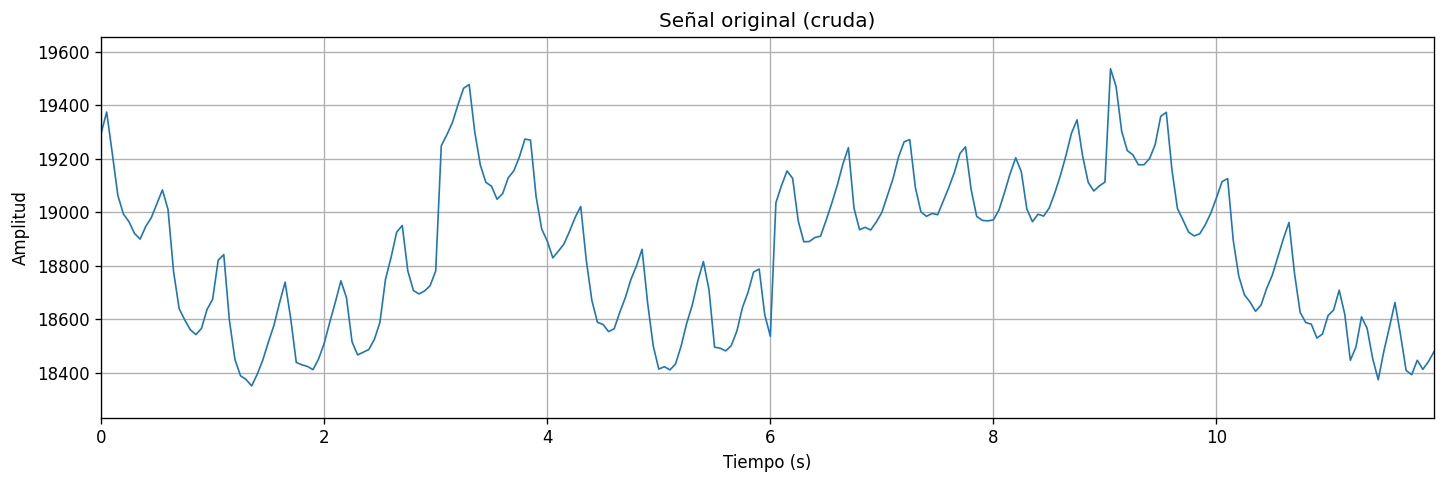

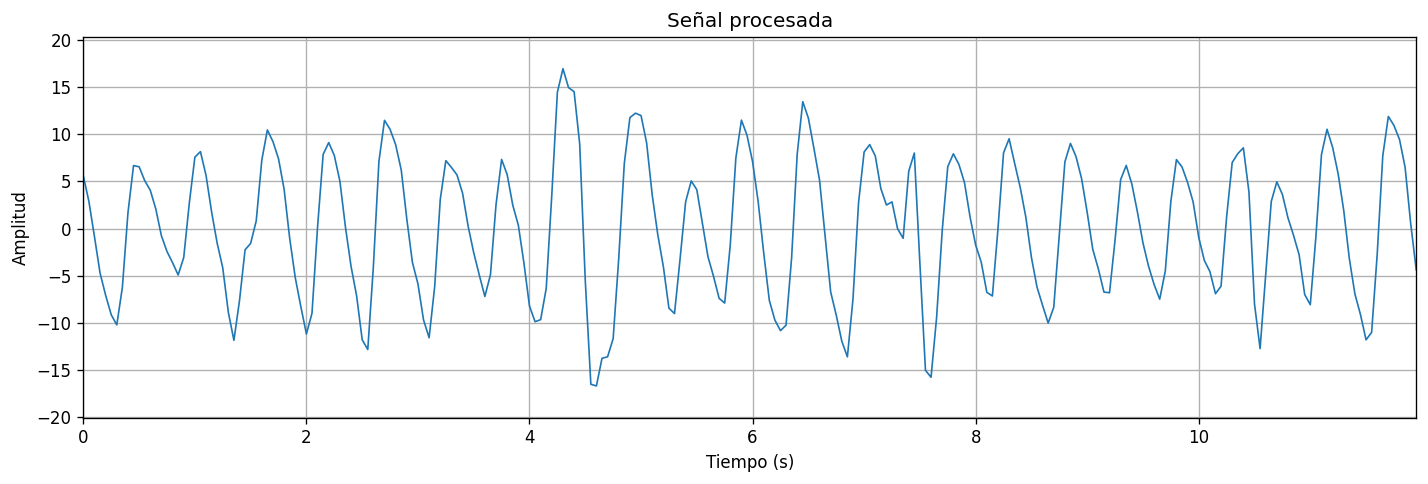

CancelledError: 

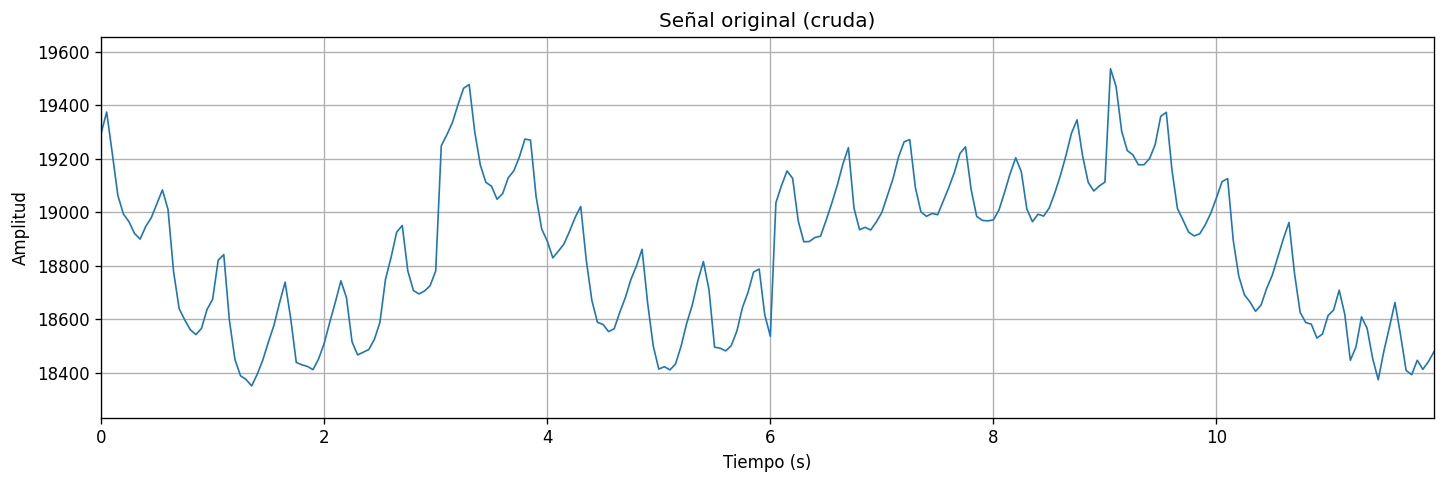

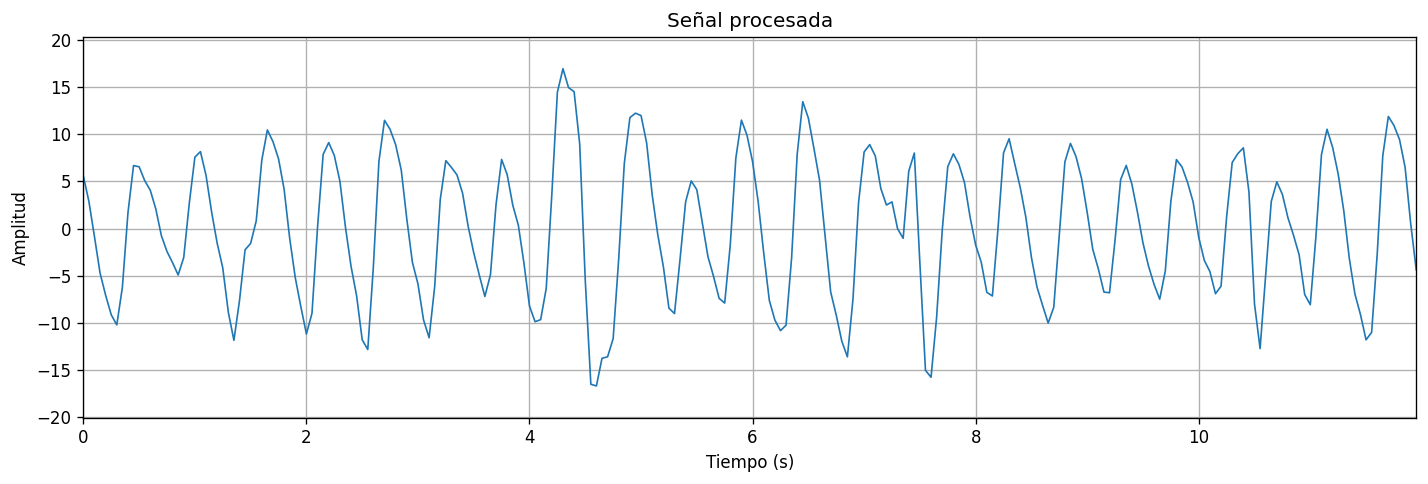

In [ ]:
%matplotlib inline
import time
import asyncio
import struct
import json
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from bleak import BleakClient
from scipy.signal import butter, filtfilt, find_peaks
import ipywidgets as widgets

import imageio.v2 as imageio

# =============================================================================
# Configuración
# =============================================================================

address = "f2:2b:66:04:27:68"
MODEL_NBR_UUID = "2A39"

metadata = {
    "infinitime_version": 1.14,
    "led_current_mA": 12,
    "delay_ms": 50,
    "description": "steady hand led12"
}

# =============================================================================
# Generator BLE
# =============================================================================

async def main(address):
    async with BleakClient(address) as client:
        while True:
            raw_data = await client.read_gatt_char(MODEL_NBR_UUID)
            int_array = np.array(list(struct.unpack('<64H', raw_data)))
            yield int_array
            await asyncio.sleep(2)

# =============================================================================
# Salidas
# =============================================================================

timestamp = str(int(time.time()))
os.makedirs("data", exist_ok=True)
os.makedirs(f"plots/{timestamp}", exist_ok=True)

data_file = open(f"data/{timestamp}_data_10hz.csv", "w")
time_file = open(f"data/{timestamp}_time.csv", "w")

with open(f"data/{timestamp}_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

# =============================================================================
# Botón de marcas
# =============================================================================

def click(arg):
    with open(f"data/{timestamp}_mark.csv", "a") as mark_file:
        mark_file.write(str(time.time()) + "\n")
        mark_file.flush()
        print("mark")

button = widgets.Button(description="mark")
button.on_click(click)

# =============================================================================
# Estado global
# =============================================================================

prev_len = 0
full_signal = None
dt = metadata["delay_ms"] / 1000.0

# =============================================================================
# Video (imageio)
# =============================================================================

raw_writer = None
proc_writer = None

video_fps = 30
RAW_MP4 = f"plots/{timestamp}/raw.mp4"
PROC_MP4 = f"plots/{timestamp}/processed.mp4"

def ensure_writers_initialized():
    global raw_writer, proc_writer
    if raw_writer is None:
        raw_writer = imageio.get_writer(
            RAW_MP4, fps=video_fps,
            codec="libx264", pixelformat="yuv420p",
            macro_block_size=1
        )
    if proc_writer is None:
        proc_writer = imageio.get_writer(
            PROC_MP4, fps=video_fps,
            codec="libx264", pixelformat="yuv420p",
            macro_block_size=1
        )

def fig_to_rgb_uint8(fig):
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return rgba[..., :3].copy()

# =============================================================================
# Filtro
# =============================================================================

def bandpass_filter(signal, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, signal)

# =============================================================================
# Render fluido
# =============================================================================

WINDOW_SAMPLES = 240
fs = 10

REFRESH_EVERY_N_SAMPLES = 2
ANIM_DELAY_SEC = 0.002

# 🔹 EJE X POSITIVO (0 → ventana)
x_buf = np.linspace(0, (WINDOW_SAMPLES-1)*dt, WINDOW_SAMPLES)

raw_buf = np.zeros(WINDOW_SAMPLES)
proc_buf = np.zeros(WINDOW_SAMPLES)
raw_history = []

FIGSIZE = (12, 4)
DPI = 120

# --- FIGURA RAW ---
fig_raw, ax_raw = plt.subplots(figsize=FIGSIZE, dpi=DPI)
line_raw, = ax_raw.plot(x_buf, raw_buf, lw=1)
ax_raw.set_title("Señal original (cruda)")
ax_raw.set_xlabel("Tiempo (s)")
ax_raw.set_ylabel("Amplitud")
ax_raw.grid(True)
ax_raw.set_xlim(x_buf[0], x_buf[-1])
ax_raw.set_ylim(-10, 10)
fig_raw.tight_layout(pad=0.6)

# --- FIGURA PROCESADA ---
fig_proc, ax_proc = plt.subplots(figsize=FIGSIZE, dpi=DPI)
line_proc, = ax_proc.plot(x_buf, proc_buf, lw=1)
title_proc = ax_proc.set_title("Señal procesada")
ax_proc.set_xlabel("Tiempo (s)")
ax_proc.set_ylabel("Amplitud")
ax_proc.grid(True)
ax_proc.set_xlim(x_buf[0], x_buf[-1])
ax_proc.set_ylim(-1, 1)
fig_proc.tight_layout(pad=0.6)

# =============================================================================
# Callback principal
# =============================================================================

frame_counter = 0

def foo(agg, a1, a2):
    global prev_len, full_signal, frame_counter
    global raw_history, raw_buf, proc_buf

    full_signal = agg.copy()

    new_segment = agg[prev_len:]
    prev_len = len(agg)

    t0 = time.time()
    for i, v in enumerate(new_segment):
        time_file.write(f"{t0 + i*dt}\n")
        data_file.write(f"{int(v)}\n")
    time_file.flush()
    data_file.flush()

    if len(new_segment) == 0:
        return

    ensure_writers_initialized()

    for v in new_segment.astype(float):
        raw_history.append(v)
        if len(raw_history) > 5000:
            raw_history = raw_history[-2500:]

        raw_buf[:-1] = raw_buf[1:]
        raw_buf[-1] = v

        recent = np.array(raw_history[-WINDOW_SAMPLES:], dtype=float)
        if len(recent) >= 20:
            ppg = recent - np.min(recent)
            try:
                filt = bandpass_filter(ppg, 0.5, 3.0, fs)
                proc_val = float(filt[-1])
            except Exception:
                proc_val = 0.0
        else:
            proc_val = 0.0

        proc_buf[:-1] = proc_buf[1:]
        proc_buf[-1] = proc_val

        frame_counter += 1

        if frame_counter % REFRESH_EVERY_N_SAMPLES == 0:
            line_raw.set_ydata(raw_buf)
            line_proc.set_ydata(proc_buf)

            rmin, rmax = raw_buf.min(), raw_buf.max()
            pad = max(1e-3, 0.1 * (rmax - rmin))
            ax_raw.set_ylim(rmin - pad, rmax + pad)

            pmin, pmax = proc_buf.min(), proc_buf.max()
            padp = max(1e-3, 0.1 * (pmax - pmin))
            ax_proc.set_ylim(pmin - padp, pmax + padp)

            raw_writer.append_data(fig_to_rgb_uint8(fig_raw))
            proc_writer.append_data(fig_to_rgb_uint8(fig_proc))

            display.clear_output(wait=True)
            display.display(button)
            display.display(fig_raw)
            display.display(fig_proc)

        if ANIM_DELAY_SEC > 0:
            time.sleep(ANIM_DELAY_SEC)

# =============================================================================
# Ejecución
# =============================================================================

try:
    display.clear_output(wait=True)
    display.display(button)
    display.display(fig_raw)
    display.display(fig_proc)

    gen = main(address)
    await hrs_analysis_tools.process(gen, iteration_listener_func=foo)

finally:
    data_file.close()
    time_file.close()

    if raw_writer is not None:
        raw_writer.close()
    if proc_writer is not None:
        proc_writer.close()
    
    # =============================================================================
# PNG finales: señal completa (RAW + FILTRADA)
# =============================================================================

    if full_signal is not None and len(full_signal) > 0:

        samples_to_cut = int(10 / dt)  # recorta 10 s al inicio y al final

        if len(full_signal) > 2 * samples_to_cut:

            trimmed_signal = full_signal[samples_to_cut:-samples_to_cut]
            t = np.arange(len(trimmed_signal)) * dt

            # -------- RAW COMPLETA --------
            fig, ax = plt.subplots(figsize=(16, 5))
            ax.plot(t, trimmed_signal, linewidth=0.6)
            ax.set_title("PPG completa (sin primeros y últimos 10 s) – cruda")
            ax.set_xlabel("Tiempo (s)")
            ax.set_ylabel("Amplitud")
            ax.grid(True)
            fig.tight_layout()

            fig.savefig(
                f"plots/{timestamp}/ppg_full_raw_trimmed.png",
                dpi=200,
                bbox_inches="tight"
            )
            plt.close(fig)

            # -------- FILTRADA COMPLETA --------
            fs_full = 1 / dt
            filtered_full = bandpass_filter(
                trimmed_signal - np.min(trimmed_signal),
                lowcut=0.5,
                highcut=3.0,
                fs=fs_full
            )

            fig, ax = plt.subplots(figsize=(16, 5))
            ax.plot(t, filtered_full, linewidth=1, color="red")
            ax.set_title("PPG completa (sin primeros y últimos 10 s) – filtrada")
            ax.set_xlabel("Tiempo (s)")
            ax.set_ylabel("Amplitud")
            ax.grid(True)
            fig.tight_layout()

            fig.savefig(
                f"plots/{timestamp}/ppg_full_filtered_trimmed.png",
                dpi=200,
                bbox_inches="tight"
            )
            plt.close(fig)

        else:
            print("⚠️ Señal demasiado corta para generar PNG completos")


print("Videos generados:")
print(" -", RAW_MP4)
print(" -", PROC_MP4)


In [22]:
pip install opencv-python


   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   --- ------------------------------------ 3.4/39.0 MB 18.3 MB/s eta 0:00:02
   -------- ------------------------------- 8.1/39.0 MB 20.8 MB/s eta 0:00:02
   ------------- -------------------------- 12.8/39.0 MB 21.2 MB/s eta 0:00:02
   ----------------- ---------------------- 16.8/39.0 MB 20.9 MB/s eta 0:00:02
   -------------------- ------------------- 20.4/39.0 MB 20.2 MB/s eta 0:00:01
   ----------------------- ---------------- 22.8/39.0 MB 18.5 MB/s eta 0:00:01
   ------------------------- -------------- 25.2/39.0 MB 17.3 MB/s eta 0:00:01
   --------------------------- ------------ 26.5/39.0 MB 16.2 MB/s eta 0:00:01
   ---------------------------- ----------- 27.8/39.0 MB 14.8 MB/s eta 0:00:01
   ------------------------------ --------- 29.4/39.0 MB 14.1 MB/s eta 0:00:01
   ------------------------------- -------- 30.9/39.0 MB 13.6 MB/s eta 0:00:01
   --------------------------------- ------ 32.2/39.0 MB 12.8 M

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
